In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [11]:
orders = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Orders.csv")
order_items = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Order_Items.csv")
customers = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Customers.csv")
payments = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Order_Payments.csv")
reviews = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Order_Reviews.csv")
products = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Products.csv")
sellers = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Sellers.csv")
translation = pd.read_csv(r"D:\Portfolio\Retail sales performance analysis-C1\Product_Category_Name_Translation.csv")

In [12]:
tables = { 
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "translation": translation
}

In [13]:
for key, df in tables.items():
    print(f"{key} {df.shape}")

orders (99441, 8)
order_items (112650, 7)
customers (99441, 5)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
translation (71, 2)


In [14]:
for name, df in tables.items():
    print(f"{name:<20} {len(df):>8,} {df.shape[1]:>6}")

orders                 99,441      8
order_items           112,650      7
customers              99,441      5
payments              103,886      5
reviews                99,224      7
products               32,951      9
sellers                 3,095      4
translation                71      2


In [15]:
for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        pct = ((nulls / len(df)) * 100).round(2)
        print(f"{name}")
        for col in nulls.index:
            print(f"\t {col} {nulls[col]} ({pct[col]}%)")

orders
	 order_approved_at 160 (0.16%)
	 order_delivered_carrier_date 1783 (1.79%)
	 order_delivered_customer_date 2965 (2.98%)
reviews
	 review_comment_title 87656 (88.34%)
	 review_comment_message 58247 (58.7%)
products
	 product_category_name 610 (1.85%)
	 product_name_lenght 610 (1.85%)
	 product_description_lenght 610 (1.85%)
	 product_photos_qty 610 (1.85%)
	 product_weight_g 2 (0.01%)
	 product_length_cm 2 (0.01%)
	 product_height_cm 2 (0.01%)
	 product_width_cm 2 (0.01%)


In [16]:
for name, df in tables.items():
    print(f"\t{name}:")
    df.info()

	orders:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
	order_items:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_i

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [18]:
for name, df in tables.items():
    print(f"\t{name}:")
    df.info()

	orders:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB
	order_items:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype        

In [19]:
for name, df in tables.items():
    print(f"{name}: \n\n{df.describe()}")

orders: 

         order_purchase_timestamp           order_approved_at  \
count                       99441                       99281   
mean   2017-12-31 08:43:12.776581  2017-12-31 18:35:24.098800   
min           2016-09-04 21:15:19         2016-09-15 12:16:38   
25%           2017-09-12 14:46:19         2017-09-12 23:24:16   
50%           2018-01-18 23:04:36         2018-01-19 11:36:13   
75%           2018-05-04 15:42:16         2018-05-04 20:35:10   
max           2018-10-17 17:30:18         2018-09-03 17:40:06   

      order_delivered_carrier_date order_delivered_customer_date  \
count                        97658                         96476   
mean    2018-01-04 21:49:48.138278    2018-01-14 12:09:19.035542   
min            2016-10-08 10:34:01           2016-10-11 13:46:32   
25%     2017-09-15 22:28:50.250000    2017-09-25 22:07:22.250000   
50%            2018-01-24 16:10:58    2018-02-02 19:28:10.500000   
75%            2018-05-08 13:37:45    2018-05-15 22:48:52.250


order_items: 

       order_item_id         shipping_limit_date          price  freight_value
count  112650.000000                      112650  112650.000000  112650.000000
mean        1.197834  2018-01-07 15:36:52.192685     120.653739      19.990320
min         1.000000         2016-09-19 00:15:34       0.850000       0.000000
25%         1.000000  2017-09-20 20:57:27.500000      39.900000      13.080000
50%         1.000000         2018-01-26 13:59:35      74.990000      16.260000
75%         1.000000  2018-05-10 14:34:00.750000     134.900000      21.150000
max        21.000000         2020-04-09 22:35:08    6735.000000     409.680000
std         0.705124                         NaN     183.633928      15.806405
customers: 

       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max 

In [20]:
for name, df in tables.items():
    print(f"{name}: \n\n{df.describe(include = 'O')}")

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"{name}: \n\n{df.describe(include = 'O')}")


orders: 

                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status  
count         99441  
unique            8  
top       delivered  
freq          96478  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"{name}: \n\n{df.describe(include = 'O')}")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

order_items: 

                                order_id                        product_id  \
count                             112650                            112650   
unique                             98666                             32951   
top     8272b63d03f5f79c56e9e4120aec44ef  aca2eb7d00ea1a7b8ebd4e68314663af   
freq                                  21                               527   

                               seller_id  
count                             112650  
unique                              3095  
top     6560211a19b47992c3666cc44a7e94c0  
freq                                2033  
customers: 

                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1              

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"{name}: \n\n{df.describe(include = 'O')}")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

payments: 

                                order_id payment_type
count                             103886       103886
unique                             99440            5
top     fa65dad1b0e818e3ccc5cb0e39231352  credit_card
freq                                  29        76795
reviews: 

                               review_id                          order_id  \
count                              99224                             99224   
unique                             98410                             98673   
top     c444278834184f72b1484dfe47de7f97  c88b1d1b157a9999ce368f218a407141   
freq                                   3                                 3   

       review_comment_title review_comment_message  
count                 11568                  40977  
unique                 4527                  36159  
top               Recomendo              Muito bom  
freq                    423                    230  
products: 

                              product_i

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"{name}: \n\n{df.describe(include = 'O')}")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14732\3415294780.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mi

In [21]:
for name, col in tables.items():
    print(f"{name}: \n{col.columns}")

orders: 
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')
order_items: 
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
customers: 
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
payments: 
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')
reviews: 
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')
products: 
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos

In [22]:
print(f"Orders - duplictes: {orders.duplicated('order_id').sum()}")
print(f"order_items - duplictes: {order_items.duplicated(['order_id', 'order_item_id']).sum()}")
print(f"customers - duplictes: {customers.duplicated('customer_id').sum()}")
print(f"payments - duplictes: {payments.duplicated('order_id').sum()}")
print(f"reviews - duplictes: {reviews.duplicated('review_id').sum()}")
print(f"reviews - duplictes: {reviews.duplicated('order_id').sum()}")
print(f"products - duplictes: {products.duplicated('product_id').sum()}")
print(f"sellers - duplictes: {sellers.duplicated('seller_id').sum()}")

Orders - duplictes: 0
order_items - duplictes: 0
customers - duplictes: 0
payments - duplictes: 4446
reviews - duplictes: 814
reviews - duplictes: 551
products - duplictes: 0
sellers - duplictes: 0


In [23]:
print(f"Orders - duplictes: {orders.duplicated().sum()}")
print(f"order_items - duplictes: {order_items.duplicated().sum()}")
print(f"customers - duplictes: {customers.duplicated().sum()}")
print(f"payments - duplictes: {payments.duplicated().sum()}")
print(f"reviews - duplictes: {reviews.duplicated().sum()}")
print(f"reviews - duplictes: {reviews.duplicated().sum()}")
print(f"products - duplictes: {products.duplicated().sum()}")
print(f"sellers - duplictes: {sellers.duplicated().sum()}")

Orders - duplictes: 0
order_items - duplictes: 0
customers - duplictes: 0
payments - duplictes: 0
reviews - duplictes: 0
reviews - duplictes: 0
products - duplictes: 0
sellers - duplictes: 0


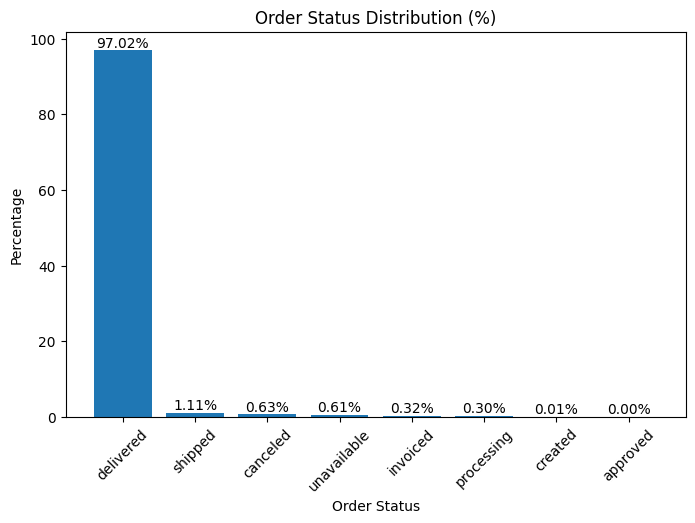

In [24]:
status_dist = orders["order_status"].value_counts(normalize = True).mul(100).round(2)

plt.figure(figsize=(8, 5))
bars = plt.bar(status_dist.index, status_dist.values)
plt.title("Order Status Distribution (%)")
plt.xlabel("Order Status")
plt.ylabel("Percentage")
plt.xticks(rotation = 45)
plt.bar_label(bars, fmt="%.2f%%")
plt.show()


In [25]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [26]:
print(f"Earliest date: {orders["order_purchase_timestamp"].min().date()}")
print(f"Latest date: {orders["order_purchase_timestamp"].max().date()}")
print(f"Earliest date: {orders["order_purchase_timestamp"].max().date() - orders["order_purchase_timestamp"].min().date()}")

Earliest date: 2016-09-04
Latest date: 2018-10-17
Earliest date: 773 days, 0:00:00


In [27]:
#####################
items_per_order = order_items.groupby("order_id").size().value_counts().sort_index()
items_pct = (items_per_order / items_per_order.sum()).round(3) * 100

for i in items_per_order.index:
    print(f"{i}: {items_per_order[i]:6,}, {items_pct[i]:5.1f}%")
print(f"\nAvg order: {order_items.groupby('order_id').size().mean():.2f}")

1: 88,863,  90.1%
2:  7,516,   7.6%
3:  1,322,   1.3%
4:    505,   0.5%
5:    204,   0.2%
6:    198,   0.2%
7:     22,   0.0%
8:      8,   0.0%
9:      3,   0.0%
10:      8,   0.0%
11:      4,   0.0%
12:      5,   0.0%
13:      1,   0.0%
14:      2,   0.0%
15:      2,   0.0%
20:      2,   0.0%
21:      1,   0.0%

Avg order: 1.14


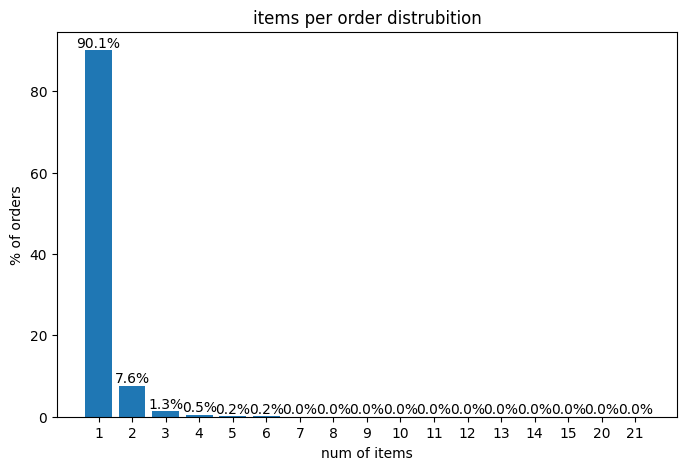

In [28]:
plt.figure(figsize=(8, 5))
bars0 = plt.bar(items_per_order.index.astype(str), items_pct)
plt.title("items per order distrubition")
plt.xlabel("num of items")
plt.ylabel("% of orders")
plt.bar_label(bars0, fmt="%.1f%%")
plt.show()

In [29]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [30]:
for col in order_items[["price", "freight_value"]]:
    print(f"\t{col}\n")
    print(f"min: {order_items[col].min()}")
    print(f"max: {order_items[col].max()}")
    print(f"mean: {order_items[col].mean():.2f}")
    print(f"median: {order_items[col].median()}")
    print(f"std: {order_items[col].std():.2f}")
    print(f"zero: {(order_items[col] == 0).sum()}")
    print(f"<0: {(order_items[col] < 0).sum()}")

	price

min: 0.85
max: 6735.0
mean: 120.65
median: 74.99
std: 183.63
zero: 0
<0: 0
	freight_value

min: 0.0
max: 409.68
mean: 19.99
median: 16.26
std: 15.81
zero: 383
<0: 0


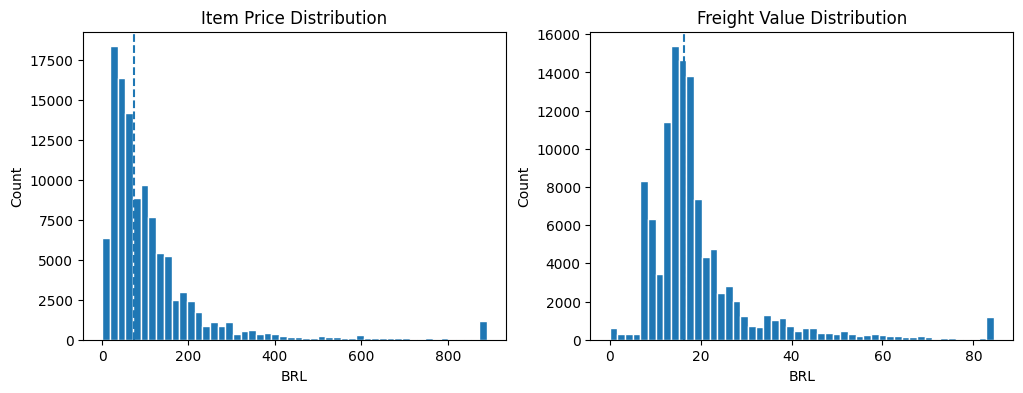

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["price", "freight_value"], ["Item Price Distribution", "Freight Value Distribution"]):
    data0 = order_items[col].clip(upper=order_items[col].quantile(.99))
    ax.hist(data0, bins = 50, edgecolor = "white")
    ax.axvline(data0.median(), linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("BRL")
    ax.set_ylabel("Count")
plt.show()

In [32]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [33]:
payments.groupby("payment_type").size()


payment_type
boleto         19784
credit_card    76795
debit_card      1529
not_defined        3
voucher         5775
dtype: int64

In [34]:
pay_dist = payments.groupby("payment_type").agg(orders=("order_id", "nunique")
    ,total=("payment_value", "sum")).sort_values("total", ascending=False).assign(pct = lambda x: x["orders"] / x["orders"].sum() * 100)
pay_dist

,orders,total,pct
payment_type,,,
credit_card,76505,12542084.19,75.236512
boleto,19784,2869361.27,19.455972
voucher,3866,379436.87,3.801900
debit_card,1528,217989.79,1.502665
not_defined,3,0.00,0.002950


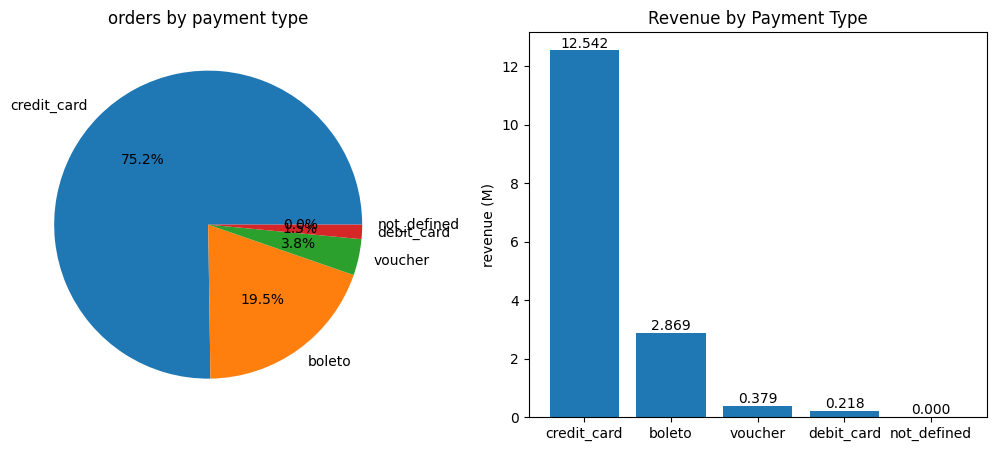

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(pay_dist["orders"], labels=pay_dist.index, autopct="%1.1f%%")
axes[0].set_title("orders by payment type")
bars1 = axes[1].bar(pay_dist.index, pay_dist["total"]/1e6)
axes[1].bar_label(bars1, fmt="%.3f")
axes[1].set_title("Revenue by Payment Type")
axes[1].set_ylabel("revenue (M)")
plt.show()

In [38]:
print(reviews)

                              review_id                          order_id  \
0      7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1      80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2      228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3      e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4      f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   
...                                 ...                               ...   
99219  574ed12dd733e5fa530cfd4bbf39d7c9  2a8c23fee101d4d5662fa670396eb8da   
99220  f3897127253a9592a73be9bdfdf4ed7a  22ec9f0669f784db00fa86d035cf8602   
99221  b3de70c89b1510c4cd3d0649fd302472  55d4004744368f5571d1f590031933e4   
99222  1adeb9d84d72fe4e337617733eb85149  7725825d039fc1f0ceb7635e3f7d9206   
99223  efe49f1d6f951dd88b51e6ccd4cc548f  90531360ecb1eec2a1fbb265a0db0508   

       review_score review_comment_title  \
0                 4            

In [42]:
review_clean = reviews.sort_values("review_creation_date", ascending=False).drop_duplicates("order_id", keep="first")
score_dist = review_clean["review_score"].value_counts().sort_index()
score_pct  = (score_dist / score_dist.sum() * 100).round(1)

for s in score_dist.index:
    print(f"  {s}     | {score_dist[s]:>6,} | {score_pct[s]:>5.1f}%")
print(f"\n  Avg score : {review_clean['review_score'].mean():.3f}")

  1     | 11,364 |  11.5%
  2     |  3,130 |   3.2%
  3     |  8,133 |   8.2%
  4     | 19,044 |  19.3%
  5     | 57,002 |  57.8%

  Avg score : 4.086


In [47]:
bars2 = ax.bar([str(s) for s in score_dist.index], score_dist.values,  edgecolor="white")
bars2

<BarContainer object of 5 artists>

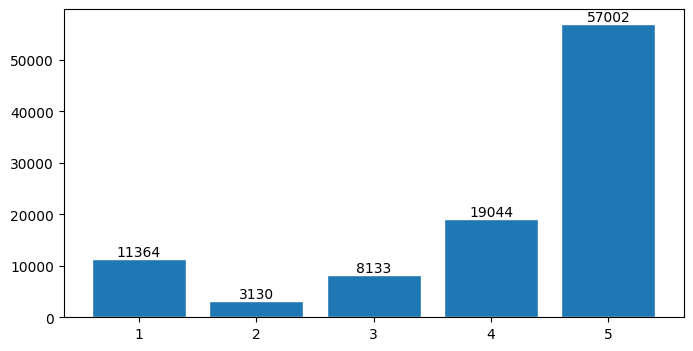

In [53]:
fig, ax = plt.subplots(figsize=(8, 4))

bars2 = ax.bar(
    [str(s) for s in score_dist.index],
    score_dist.values,
    edgecolor="white"
)
for bar, v in zip(bars2, score_dist.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{v}",
        ha='center',
        va='bottom'
    )


Text(0.5, 1.0, 'Top 10 States by Customer Count')

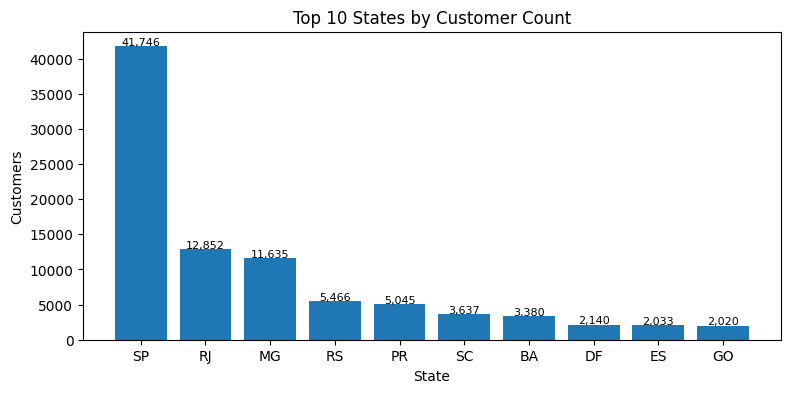

In [56]:
state_cnt = customers["customer_state"].value_counts().head(10)
fig, ax   = plt.subplots(figsize=(9, 4))
bars = ax.bar(state_cnt.index, state_cnt.values)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
            f"{bar.get_height():,}", ha="center", fontsize=8)
ax.set_xlabel("State"); ax.set_ylabel("Customers")
ax.set_title("Top 10 States by Customer Count")